# Carga de datos

In [23]:
%pip install kaggle

In [24]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [25]:
import json
import os
import shutil

# Cargar credenciales desde kaggle.json
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

# Autenticar y descargar el dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('sachinkumar413/cxr-2-classes', path='data_taller', unzip=True)



Dataset URL: https://www.kaggle.com/datasets/sachinkumar413/cxr-2-classes


# Exploración de Datos

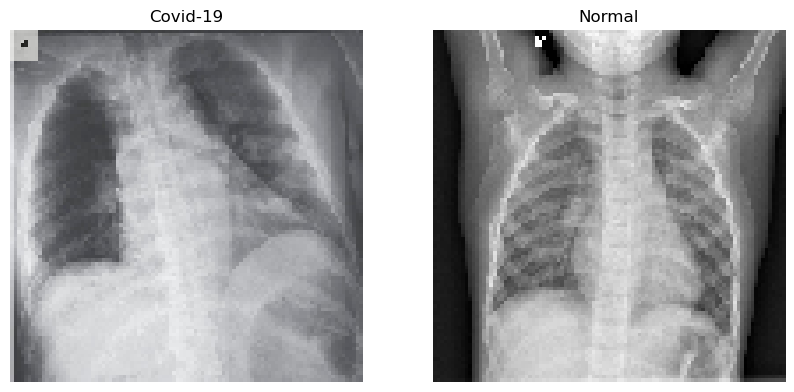

Total de imágenes: 1675
Número de imágenes por categoría:
Covid-19: 825
Normal: 850


In [26]:
import matplotlib.pyplot as plt
from tensorflow import keras
import os

# Directorio de datos y obtención de las categorías
data_dir = 'data_taller'
asl_categories = os.listdir(data_dir)

# Visualización de una imagen de cada categoría
plt.figure(figsize=(10, 50))
for i, category in enumerate(asl_categories):
    folder = os.path.join(data_dir, category)
    image_file = os.listdir(folder)[0]
    img_path = os.path.join(folder, image_file)
    img = keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
    plt.subplot(int(len(asl_categories)/2) + 1, 2, i+1)
    plt.title(category)
    plt.imshow(img)
    plt.axis('off')
plt.show()

# Análisis del tamaño y distribución de clases
image_count = {}
total_images = 0
for category in asl_categories:
    folder = os.path.join(data_dir, category)
    count = len(os.listdir(folder))
    image_count[category] = count
    total_images += count

print(f"Total de imágenes: {total_images}")
print("Número de imágenes por categoría:")
for category, count in image_count.items():
    print(f"{category}: {count}")

# Preprocesamiento de Datos

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Recopilación de rutas y etiquetas
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir)
             for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]

# Crear DataFrame
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Dividir en entrenamiento (70%), validación (20%) y test (10%)
train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=13)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=13)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1675
Entrenamiento: 1172
Validación: 336
Test: 167


## Estrategias de Preprocesamiento y Data Augmentation

#### Reescalado y Normalización
Elegimos el tamaño de redimensionamiento a (100,100) para preservar detalles relevantes y eficiencia computacional. Tamaños mayores aumentarían significativamente el tiempo de entrenamiento sin necesariamente mejorar el rendimiento para las características que buscamos detectar. Escalamos los valores de píxeles de [0-255] a [0-1] para mejorar la estabilidad numérica durante el entrenamiento. Esto es especialmente importante para radiografías que pueden tener alto contraste en ciertas regiones.

### Justificación del Data Augmentation

Las radiografías de tórax pueden presentar variaciones en la posición del paciente durante la captura. Una rotación moderada de mas o menos 20 grados simula estas variaciones sin distorsionar características anatómicas críticas. No usamos valores mayores ya que la posición anatómica en radiografías suele mantener una orientación estándar.

Aunque los pulmones tienen cierta simetría, existen diferencias entre el pulmón derecho e izquierdo. El volteo horizontal ayuda al modelo a concentrarse en los patrones de COVID-19 (opacidades y consolidaciones) independientemente del lado donde aparezcan, mejorando la generalización. Deliberadamente evitamos a proposito un volteo vertical ya que alteraría la anatomía de forma no realista como el corazón y diafragma en posiciones incorrectas.


### Beneficios del Enfoque Adoptado

La mitigación del sobreajuste es importante dado nuestro conjunto de datos moderado (1,675 imágenes), el data augmentation efectivamente aumenta la variabilidad de los ejemplos de entrenamiento. Por otro lado, nuestras transformaciones son conservadoras para preservar los patrones radiológicos asociados con COVID-19 como opacidades bilaterales, patrón de vidrio esmerilado, consolidaciones. También generamos variaciones en tiempo real durante el entrenamiento, lo que evita la necesidad de almacenar múltiples versiones transformadas de cada imagen.


# Generador de imágenes

In [28]:
from tensorflow import keras

# Generador para entrenamiento con data augmentation
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# Generador para validación y test (solo reescala)
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Creación de generadores a partir de los DataFrames
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)

Found 1172 validated image filenames belonging to 2 classes.
Found 336 validated image filenames belonging to 2 classes.
Found 167 validated image filenames belonging to 2 classes.


# Construcción del Modelo CNN

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Construcción del modelo CNN
model = Sequential([
    # Primera capa convolucional: extrae características básicas
    Conv2D(16, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D((2, 2)),

    # Segunda capa convolucional: extrae características más complejas
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Aplanamiento para conectar con las capas densas
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(len(asl_categories), activation='softmax')  # Capa de salida para clasificación
])

# Resumen del modelo para verificar la arquitectura
model.summary()

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │       270,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,986 (1.05 MB)

 Trainable params: 275,986 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

## Justificación de la Arquitectura CNN

La arquitectura diseñada para este modelo de clasificación de radiografías de tórax se ha hecho considerando las características específicas de nuestro conjunto de datos.

### Estructura de capas convolucionales
Hemos optado por una arquitectura con dos capas convolucionales seguidas de capas de pooling por varias razones. La primera capa (16 filtros de 3x3), diseñada para detectar características básicas como bordes, contornos y texturas simples que son relevantes en radiografías. Los filtros pequeños (3x3) permiten capturar detalles finos sin aumentar excesivamente el número de parámetros. Por otro lado, la segunda capa (32 filtros de 3x3) duplica el número de filtros para detectar patrones más complejos y abstractos a partir de las características básicas detectadas en la primera capa. Esta progresión de filtros sigue el principio de aumentar la profundidad de características mientras se reduce la dimensionalidad espacial.

### Elección de MaxPooling2D
Seleccionamos MaxPooling2D (2x2) en lugar de AveragePooling2D por varias razones. Las radiografías de tórax con COVID-19 presentan opacidades y patrones de "vidrio esmerilado" que son características destacadas que MaxPooling puede preservar mejor, ya que captura los valores máximos en cada región. MaxPooling ayuda a lograr invariancia a pequeñas traslaciones, lo cual es beneficioso dado que las estructuras pulmonares pueden aparecer en posiciones ligeramente diferentes entre pacientes. También reduce el tamaño de los mapas de características a la mitad después de cada capa convolucional, disminuyendo la carga computacional.

### Función de activación ReLU
La función Rectified Linear Unit es la activación en las capas convolucionales y densas por varias razones. Una es su eficiencia computacional comparada con funciones sigmoides o tangente hiperbólica. Otra es que ayuda a mitigar el problema del desvanecimiento del gradiente durante el entrenamiento. También introduce no-linealidad necesaria para aprender patrones complejos sin afectar significativamente el tiempo de entrenamiento.

### Capa Flatten
Esta capa es necesaria para transformar los mapas de características 2D resultantes de las capas convolucionales en un vector 1D que pueda ser procesado por las capas densas. En nuestro caso, convierte los 23x23x32 mapas en un vector de 16,928 características.

### Capas densas y Dropout
La capa densa con 16 neuronas fue seleccionada para reducir significativamente la dimensionalidad y extraer características de alto nivel relevantes para la clasificación. Un número mayor podría llevar a sobreajuste en este conjunto de datos relativamente pequeño. La capa Dropout tiene una tasa de abandono del 20% que se eligió como un equilibrio para prevenir el sobreajuste sin sacrificar demasiada capacidad de aprendizaje. Durante el entrenamiento, apaga aleatoriamente el 20% de las neuronas, forzando a la red a aprender representaciones más robustas.


# Compilación

In [30]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Definición de Callbacks

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True,
                                   monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

# Entrenamiento del Modelo


In [32]:
import tensorflow as tf

with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.5766 - loss: 0.6310 - val_accuracy: 0.9286 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9414 - loss: 0.4006 - val_accuracy: 0.9048 - val_loss: 0.3767 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9379 - loss: 0.3722 - val_accuracy: 0.9762 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9681 - loss: 0.3299 - val_accuracy: 0.9821 - val_loss: 0.3210 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.9760 - loss: 0.3092 - val_accuracy: 0.9821 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9703 - loss: 0.3024 - val_accuracy: 0.9762 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9703 - loss: 0.3037 -

# Evaluación del modelo

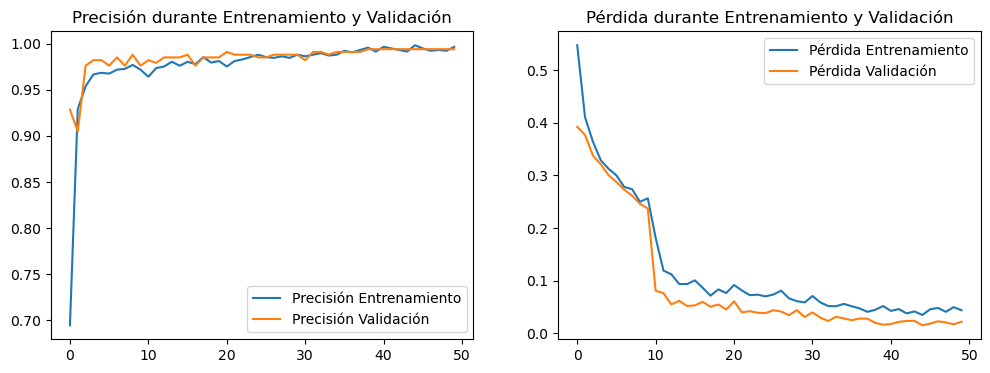

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step


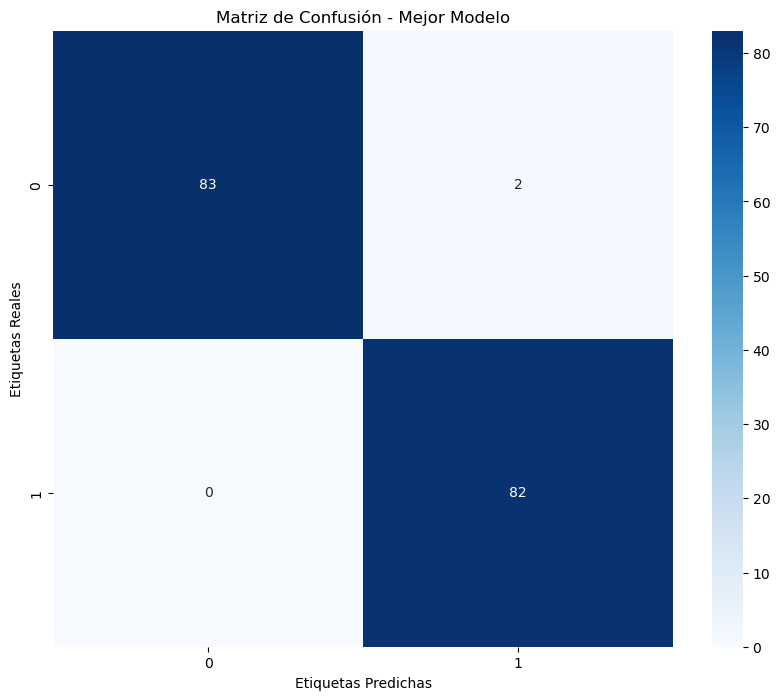

              precision    recall  f1-score   support

    Covid-19       1.00      0.98      0.99        85
      Normal       0.98      1.00      0.99        82

    accuracy                           0.99       167
   macro avg       0.99      0.99      0.99       167
weighted avg       0.99      0.99      0.99       167



In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.models import load_model

# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

# Cargar el modelo guardado con el mejor desempeño en validación
best_model = load_model('best_model.keras')

# Evaluar el modelo en el conjunto de test
test_gen.reset()
predicciones = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(predicciones, axis=1)
y_test = test_gen.classes

# Calcular y mostrar la matriz de confusión y el reporte de clasificación
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Mejor Modelo')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

print(classification_report(y_test, y_pred, target_names=asl_categories, zero_division=0))

# Experimentos

In [34]:
# Experimento 1: Modelo con mayor profundidad (más capas convolucionales)
model_exp1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax') 
])


model_exp1.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_exp1.summary()

with tf.device('/device:GPU:0'):
    history_exp1 = model_exp1.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,  
        callbacks=callbacks
    )


best_model_exp1 = load_model('best_model_exp1.keras')
test_gen.reset()
predictions_exp1 = best_model_exp1.predict(test_gen, verbose=1)
y_pred_exp1 = np.argmax(predictions_exp1, axis=1)
y_test = test_gen.classes

cm_exp1 = confusion_matrix(y_test, y_pred_exp1)
print("Reporte de clasificación - Experimento 1:")
print(classification_report(y_test, y_pred_exp1, target_names=asl_categories))

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       204,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,482 (892.51 KB)

 Trainable params: 228,482 (892.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.6127 - loss: 0.6168 - val_accuracy: 0.9792 - val_loss: 0.0957 - learning_rate: 0.0010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.9466 - loss: 0.1680 - val_accuracy: 0.9821 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9626 - loss: 0.0954 - val_accuracy: 0.9792 - val_loss: 0.0878 - learning_rate: 0.0010
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9766 - loss: 0.0703 - val_accuracy: 0.9702 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9707 - loss: 0.0990 - val_accuracy: 0.9732 - val_loss: 0.0955 - learning_rate: 0.0010
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9743 - loss: 0.0875 - val_accuracy: 0.9851 - val_loss: 0.0664 - learning_rate: 0.0010
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9761 - loss: 0.0783 - 

In [35]:
# Experimento 2: Modificar la tasa de Dropout
model_exp2 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')  
])


model_exp2.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


with tf.device('/device:GPU:0'):
    history_exp2 = model_exp2.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks
    )


best_model_exp2 = load_model('best_model_exp2.keras')
test_gen.reset()
predictions_exp2 = best_model_exp2.predict(test_gen, verbose=1)
y_pred_exp2 = np.argmax(predictions_exp2, axis=1)

cm_exp2 = confusion_matrix(y_test, y_pred_exp2)
print("Reporte de clasificación - Experimento 2:")
print(classification_report(y_test, y_pred_exp2, target_names=asl_categories))

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.6880 - loss: 0.6440 - val_accuracy: 0.9762 - val_loss: 0.1005 - learning_rate: 0.0010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9636 - loss: 0.1171 - val_accuracy: 0.9851 - val_loss: 0.0623 - learning_rate: 0.0010
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9803 - loss: 0.0589 - val_accuracy: 0.9792 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9784 - loss: 0.0711 - val_accuracy: 0.9851 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9763 - loss: 0.0652 - val_accuracy: 0.9792 - val_loss: 0.0508 - learning_rate: 0.0010
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9733 - loss: 0.0738 - val_accuracy: 0.9762 - val_loss: 0.0834 - learning_rate: 0.0010
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9767 - loss: 0.0708 - 

In [ ]:
# Experimento 4: Cambiar el tamaño de los filtros
model_exp4 = Sequential([
    Conv2D(16, (5, 5), activation='relu', input_shape=(100, 100, 3)), 
    MaxPooling2D((2, 2)),
    Conv2D(32, (5, 5), activation='relu'),  
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax')
])

model_exp4.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

with tf.device('/device:GPU:0'):
    history_exp4 = model_exp4.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks
    )


best_model_exp4 = load_model('best_model_exp4.keras')
test_gen.reset()
predictions_exp4 = best_model_exp4.predict(test_gen, verbose=1)
y_pred_exp4 = np.argmax(predictions_exp4, axis=1)


cm_exp4 = confusion_matrix(y_test, y_pred_exp4)
print("Reporte de clasificación - Experimento 4:")
print(classification_report(y_test, y_pred_exp4, target_names=asl_categories))

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.5725 - loss: 0.6651 - val_accuracy: 0.8869 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9534 - loss: 0.3883 - val_accuracy: 0.9792 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9740 - loss: 0.3479 - val_accuracy: 0.9375 - val_loss: 0.3564 - learning_rate: 0.0010
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.9611 - loss: 0.3489 - val_accuracy: 0.9762 - val_loss: 0.3281 - learning_rate: 0.0010
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9748 - loss: 0.3166 - val_accuracy: 0.9762 - val_loss: 0.3119 - learning_rate: 0.0010
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.9827 - loss: 0.2867 - val_accuracy: 0.9851 - val_loss: 0.2945 - learning_rate: 0.0010
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9707 - loss: 0.2838 - 

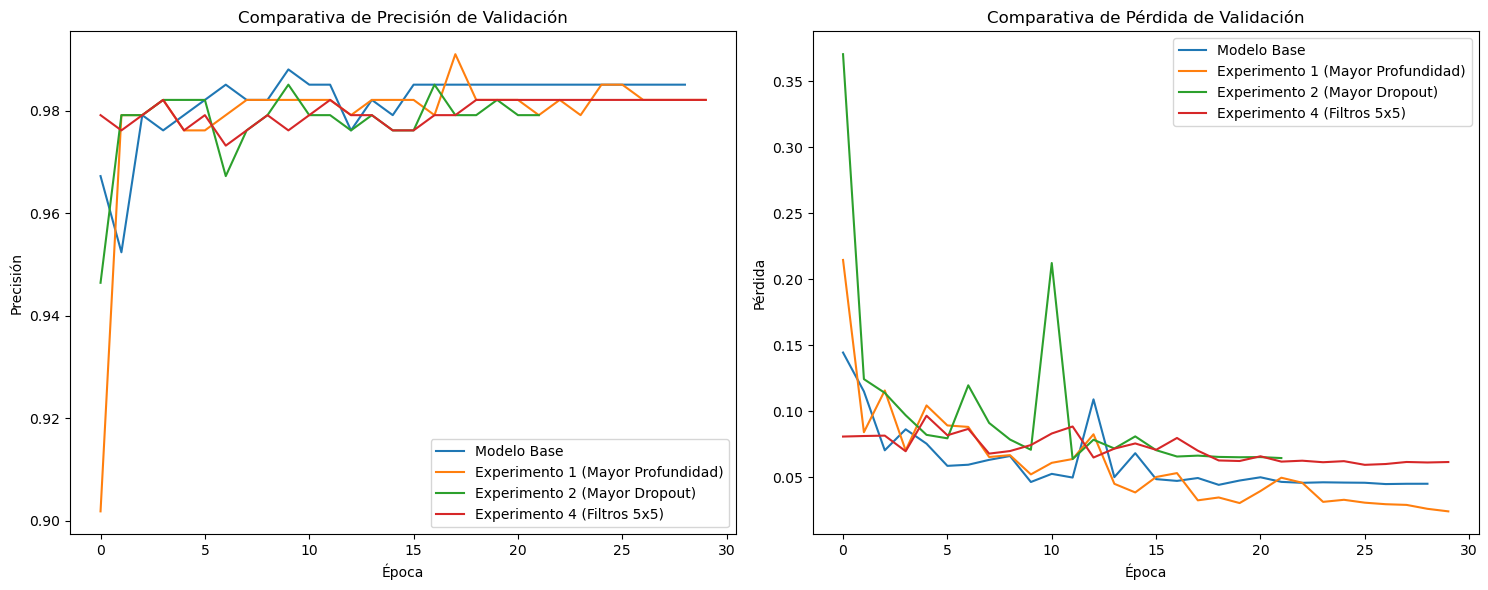

,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Modelo Base,0.982036,0.981999,0.982138,0.982033
1,Experimento 1,0.988024,0.988095,0.988235,0.988024
2,Experimento 2,0.982036,0.981999,0.982138,0.982033
3,Experimento 4,0.982036,0.981999,0.982138,0.982033


In [ ]:

plt.figure(figsize=(15, 6))

# Comparativa de precisión de validación
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Modelo Base')
plt.plot(history_exp1.history['val_accuracy'], label='Experimento 1 (Mayor Profundidad)')
plt.plot(history_exp2.history['val_accuracy'], label='Experimento 2 (Mayor Dropout)')
plt.plot(history_exp4.history['val_accuracy'], label='Experimento 4 (Filtros 5x5)')
plt.title('Comparativa de Precisión de Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Comparativa de pérdida de validación
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Modelo Base')
plt.plot(history_exp1.history['val_loss'], label='Experimento 1 (Mayor Profundidad)')
plt.plot(history_exp2.history['val_loss'], label='Experimento 2 (Mayor Dropout)')
plt.plot(history_exp4.history['val_loss'], label='Experimento 4 (Filtros 5x5)')
plt.title('Comparativa de Pérdida de Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

import pandas as pd

modelos = ['Modelo Base', 'Experimento 1', 'Experimento 2', 'Experimento 4']


def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=asl_categories, output_dict=True)
    accuracy = report['accuracy']
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    return accuracy, macro_precision, macro_recall, macro_f1


metrics_base = get_metrics(y_test, y_pred)
metrics_exp1 = get_metrics(y_test, y_pred_exp1)
metrics_exp2 = get_metrics(y_test, y_pred_exp2)
metrics_exp4 = get_metrics(y_test, y_pred_exp4)


metrics_df = pd.DataFrame({
    'Modelo': modelos,
    'Accuracy': [metrics_base[0], metrics_exp1[0], metrics_exp2[0], metrics_exp4[0]],
    'Precision (Macro)': [metrics_base[1], metrics_exp1[1], metrics_exp2[1], metrics_exp4[1]],
    'Recall (Macro)': [metrics_base[2], metrics_exp1[2], metrics_exp2[2], metrics_exp4[2]],
    'F1-Score (Macro)': [metrics_base[3], metrics_exp1[3], metrics_exp2[3], metrics_exp4[3]]
})


display(metrics_df)

# Comparación de Experimentos

### ¿Qué impacto tiene la profundidad de la red y el número de filtros en la capacidad de aprendizaje?

El experimento 1, que aumentó la profundidad del modelo, obtuvo la mayor precisión de validación (0.988) y una menor pérdida de validación de forma más consistente al final del entrenamiento. Esto indica que una arquitectura más profunda puede captar patrones más complejos, lo cual mejora la capacidad de aprendizaje del modelo. Por otro lado, el experimento 4, que modificó el tamaño del filtro a 5x5, mostró un rendimiento similar al modelo base, con una precisión final muy cercana (≈0.982), pero con una pérdida de validación un poco más alta. Esto sugiere que el aumento del tamaño de filtro no siempre garantiza una mejor capacidad de aprendizaje, especialmente cuando ya se capturan bien los patrones relevantes con filtros más pequeños y eficientes como los de 3x3.



### ¿Cómo influyen las técnicas de regularización (por ejemplo, Dropout) en la capacidad de generalización del modelo?

El experimento 2, que aumentó el dropout, mantuvo métricas similares al modelo base, pero con más variabilidad en la pérdida de validación. Esto sugiere que un nivel alto de regularización puede impedir que el modelo aprenda eficientemente, aunque ayuda a evitar el sobreajuste. El modelo generaliza bien, pero no logra explotar del todo su capacidad de aprendizaje. Por lo tanto, Dropout es útil para mejorar la generalización, pero debe aplicarse con un equilibrio adecuado: demasiado puede reducir la capacidad del modelo para aprender patrones relevantes.



### ¿Qué mejoras adicionales se podrían implementar para optimizar aún más el rendimiento del modelo?

Para optimizar aún más el rendimiento del modelo, se podría implementar Batch Normalization, lo cual ayudaría a estabilizar y acelerar el entrenamiento al normalizar las activaciones intermedias, además de reducir la sensibilidad a la inicialización de pesos. También se podrían ver arquitecturas más complejas como ResNet o MobileNet, aprovechando técnicas de transfer learning para reutilizar conocimientos previamente aprendidos en grandes conjuntos de datos y así mejorar la capacidad de generalización del modelo.


### Reflexión

En general, todos los modelos obtuvieron resultados buenos con precisiones superiores al 98%. El experimento 1 destacó por su rendimiento, evidenciando que una mayor capacidad de representación puede mejorar el desempeño siempre que se acompañe de una regularización adecuada. Esto sugiere que la arquitectura base es sólida, pero puede beneficiarse de una mayor profundidad y de ajustes cuidadosos en las técnicas de regularización. Como futuras líneas de trabajo, se puede evaluar el modelo en conjuntos de datos más diversos, incorporar técnicas de explicabilidad como Grad-CAM y avanzar hacia aplicaciones prácticas en entornos médicos en tiempo real.

# Conclusiones y discusión

- **¿Cómo afecta el tamaño del filtro en las capas convolucionales al rendimiento del modelo?**  
  
  El tamaño del filtro en las caas convolucionales afecta a las caracteristicas que se extraen. Si el filtro es pequeño, este tiene un costo computacional bajo y es capaz de recoger caracteristicas más específicas de las imágenes. Si el filtro es de un tamaño mayor, puede obtener características más abstractas aunque implica también un costo computacional más alto. De esta manera, se puede decir que entre más grande sea el filtro consigue información más abstracta y se demora más, por lo que su incremento en tamaño es ideal hacerlo de forma incremental después de reducir los tamaños.

- **¿Qué ventajas y desventajas presentan las diferentes estrategias de pooling (MaxPooling, AveragePooling, GlobalPooling) en la extracción de características?**  
  Discutir cómo cada tipo de pooling afecta la preservación de información y la reducción de dimensionalidad.

Para comenzar, MaxPooling se encarga de  reducir la dimensionalidad tomando el valor máximo que se encuentra en el kernel. Esto es bueno para reducir la dimensionalidad haciendo énfasis en características que se marquen mucho, aunque los detalles se pueden perder. Por otro lado, AvaragePooling en vez de tomar un valor único, promedia las ocurrencias dentro del kernel logrando suavizar los detalles que se encuentran. Sin embargo, es posible que con AvaragePooling se diluyan las características de una forma no deseada al ser el promedio de lo que se encuentra. Por último, GlobalPooling reduce todo el mapa de activación a un solo valor por canal, lo que disminuye drásticamente los parámetros y simplifica el modelo. No obstante, al eliminar por completo la información espacial, puede perder detalles relevantes sobre la ubicación de las características.

- **¿Cómo influye la profundidad de la red (número de capas convolucionales) en la capacidad de generalización y el riesgo de sobreajuste?**  
  Reflexionar sobre el balance entre una red más profunda y la necesidad de regularización para evitar el sobreajuste.

Se puede afirmar que entre más capas se le agregue a la red convolucional se puede llegar a aprender características más abstractas que se ajustan a los datos de entrada. Sin embargo, esto no es necesariamente bueno ya que a mayor profundidad aumenta la rpobabilidad del sobreajuste ya que el modelo termina entendiendo específicamente cómo funcionan los datos de entrada, lo cual lleva a un menor nivel de generalización.


- **¿Qué impacto tiene el uso de técnicas como Dropout o Batch Normalization en el entrenamiento de redes convolucionales?**  
  Explorar cómo estas técnicas contribuyen a la estabilidad del entrenamiento y a la mejora del rendimiento general del modelo.

En primer lugar, Dropout funciona apagando neuronas aleatorias en el transcurso del entrenamiento, lo cuál es útil para hacer que el modelo aprenda en varias rutas mejorando la generalización y evitando el sobreajuste ya que evita que estas neuronas estén aprendiendoce los datos. Por otro lado, el Batch Normalization funciona normalizando los valores entre los minibatch aumentando la velocidad del modelo ya que facilita que el modelo entienda los datos con los que trabaja pues estan normalizados. 
